In [ ]:
from sdk_core import configure
from sdk_core import TwMarketData
# configure()

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)


In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from backTest import BackTest

In [ ]:


folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[:5])

['20240102.parquet' '20240103.parquet' '20240104.parquet'
 '20240105.parquet' '20240108.parquet']


In [18]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[1:]): 
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = (stock_df.BidPrice1 - stock_df.RefPrice) / stock_df.RefPrice 
        stock_df['TakerSell_CloseBP'] = ((stock_df.BidPrice1 - stock_df.Close) / stock_df.BidPrice1 * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df.BidPrice1 - stock_df.FutureHigh) / stock_df.BidPrice1 * 10000)
        PriceCondition = (stock_df.ToRef > 0) & (stock_df.ToRef < 0.05)
        AmountCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition ].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
    # break

100%|██████████| 513/513 [00:34<00:00, 15.04it/s]


In [68]:
signal_df = pd.concat(data).reset_index(drop=True)


display(signal_df[mask][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']])
#.iloc[5150:])

In [69]:
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]


In [70]:
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']]#.iloc[5150:]

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2024-01-03 09:05:00.599069,3105,141281,389,152.0,5,152.5,23,154.0,153.5,148.0,148.0,154.0,1.0,263.157895,0.027027,-50,58.0,26.0,09:05:00,2024-01-03 09:04:59.589765
1,2024-01-03 09:05:00.633669,3105,141290,394,151.5,59,152.5,23,154.0,153.5,148.0,148.0,154.0,2.0,231.023102,0.023649,-55,58.0,26.0,09:05:00,2024-01-03 09:04:59.589765
2,2024-01-03 09:05:00.633707,3105,141292,394,151.5,58,152.0,1,154.0,153.5,148.0,148.0,154.0,1.0,231.023102,0.023649,-55,58.0,26.0,09:05:00,2024-01-03 09:04:59.589765
3,2024-01-03 09:05:00.654100,3105,141295,394,151.5,58,152.5,23,154.0,153.5,148.0,148.0,154.0,2.0,231.023102,0.023649,-55,58.0,26.0,09:05:00,2024-01-03 09:04:59.589765
4,2024-01-03 09:05:02.251007,3105,141827,394,152.0,1,152.5,27,154.0,153.5,148.0,148.0,154.0,1.0,263.157895,0.027027,-55,58.0,26.0,09:05:00,2024-01-03 09:04:59.589765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4559928,2026-02-11 10:31:07.303919,8996,6049503,2576,932.0,2,934.0,1,955.0,933.0,931.0,906.0,925.0,2.0,278.969957,0.001074,-428,46.0,53.0,10:30:00,2026-02-11 10:29:59.191899
4559929,2026-02-11 10:31:11.488255,8996,6051751,2576,932.0,2,935.0,7,955.0,932.0,931.0,906.0,925.0,3.0,278.969957,0.001074,-428,46.0,53.0,10:30:00,2026-02-11 10:29:59.191899
4559930,2026-02-11 10:31:41.794909,8996,6068667,2576,932.0,2,934.0,1,955.0,932.0,931.0,906.0,925.0,2.0,278.969957,0.001074,-428,46.0,53.0,10:30:00,2026-02-11 10:29:59.191899
4559931,2026-02-11 10:31:46.786315,8996,6071340,2576,932.0,2,933.0,1,955.0,932.0,931.0,906.0,925.0,1.0,278.969957,0.001074,-428,46.0,53.0,10:30:00,2026-02-11 10:29:59.191899


In [71]:
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)

In [72]:
signal_df = signal_df[ (signal_df.TakerSell_CloseBP.abs() < 10000) & (signal_df.Date.astype(int) <20260201)].reset_index(drop=True)

In [73]:
signal_df.TakerSell_CloseBP.describe()

count    3.974021e+06
mean     7.632217e+01
std      3.098247e+02
min     -1.784387e+03
25%     -3.710575e+01
50%      1.011561e+02
75%      2.479339e+02
max      1.418919e+03
Name: TakerSell_CloseBP, dtype: float64

In [74]:
(signal_df.TakerSell_CloseBP * signal_df.BidPrice1).sum() / signal_df.BidPrice1.sum() 

np.float64(58.11060868916933)

In [75]:
signal_df.groupby('Date').QuoteCode.nunique().mean()

np.float64(37.067326732673266)

In [76]:
# signal_df = signal_df.groupby(['Date','QuoteCode']).head(1).reset_index()

<Axes: xlabel='Date'>

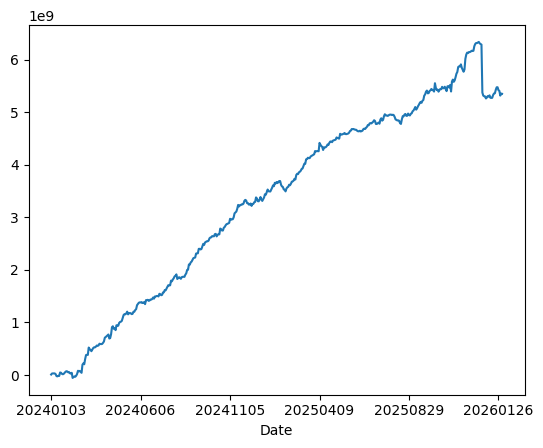

In [77]:
(((signal_df.TakerSell_CloseBP - 18) * signal_df.BidPrice1 / 10) .groupby(signal_df.Date).sum()  ) .cumsum().plot()

In [ ]:
signal_df[signal_df.TakerSell_CloseBP.abs() > 2000]

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,Date
144121,1970-01-01 09:19:16.893841+00:00,2024-02-05 09:19:16.893841,6684,6684,9520040,412987,0,0,0,0,9389,112.0,0.0,0.0,0.0,0.0,87,0,0,0,0,112.5,113.0,113.5,114.0,114.5,1,43,34,29,71,0.0,0,0.0,0,0.0,0,NaN,112.0,True,131.5,112.0,135.5,112.0,113.0,112.0,0.004464,0.205357,0.021277,0.5,44.642857,112.25,0.002232,-0.146388,-646,-2187,0.988636,1.000000,1.000000,0.005618,0.247191,1.0,61,113.0,112.0,2,0.192134,0.192134,-1.0,371,150,15767.106159,112.5,112.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2044.444444,0.000000,0.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,X,6569000.0,10000.0,-35000.0,0.0,-88000.0,0.0,1056.0,278.0,X,6569.0,20.0,inf,-8491.21223,15.0,-inf,4572.755020,0.258417,226.009083,-4898.493924,-inf,6639.511202,88.0,114.0,2024-02-05 09:14:57.910017,09:15:00,21.0,1834.0,13.0,1834.0,8.0,20240205
145138,1970-01-01 09:18:13.411742+00:00,2024-02-05 09:18:13.411742,8054,8054,9503771,396718,0,0,0,0,10613,185.5,185.0,184.5,184.0,0.0,1,52,142,520,0,186.0,187.0,188.0,189.0,190.0,1,2,5,13,80,0.0,0,0.0,0,0.0,0,NaN,184.0,True,224.0,184.0,224.0,185.0,190.0,184.0,0.005435,0.206522,0.025641,0.5,26.954178,185.75,0.009511,-0.170759,-699,-19052,0.500000,0.001399,0.074126,0.009901,0.029703,1.0,60,186.0,185.0,1,4.656032,4.656032,1.0,1258,8318,15830.588258,188.0,186.5,186.5,184.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2043.010753,-80.862534,80.753701,-13.458950,-10000.000000,-10000.000000,-10000.000000,-10000.000000,X,1877000.0,173000.0,0.0,0.0,-313000.0,0.0,-140.0,-332.0,X,1877.0,NaN,NaN,NaN,9.0,-inf,476.190476,NaN,NaN,NaN,NaN,NaN,309.0,507.0,2024-02-05 09:14:55.903827,09:15:00,5.0,1845.0,9.0,1844.0,1.0,20240205
145145,1970-01-01 09:18:14.216630+00:00,2024-02-05 09:18:14.216630,8054,8054,9503962,396909,0,0,0,0,10677,185.5,185.0,184.5,184.0,0.0,4,9,141,521,0,186.0,188.0,189.0,190.0,190.5,2,11,13,80,9,0.0,0,0.0,0,0.0,0,NaN,184.0,True,224.0,184.0,224.0,185.0,190.0,184.0,0.000000,0.211957,0.000000,0.5,26.954178,185.75,0.009511,-0.170759,-741,-19094,0.666667,0.005926,0.019259,0.017391,0.113043,1.0,64,188.0,185.0,1,0.507070,0.249873,1.0,52,9,15829.783370,187.5,186.0,186.0,184.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2043.010753,-80.862534,53.835801,-26.917900,-10000.000000,-10000.000000,-10000.000000,-10000.000000,X,1877000.0,173000.0,0.0,0.0,-313000.0,0.0,-140.0,-332.0,X,1877.0,NaN,NaN,NaN,9.0,-inf,476.190476,NaN,NaN,NaN,NaN,NaN,309.0,507.0,2024-02-05 09:14:55.903827,09:15:

In [ ]:
signal_df = signal_df[signal_df.Date == "20240105"]

In [ ]:
(((signal_df.TakerSell_CloseBP - 17) * signal_df.BidPrice1 / 10) .groupby(signal_df.Date).sum()  ) .cumsum().plot()

Error fetching stock tick data for 20240102: 'DataFrame' object has no attribute 'sort_values'


In [ ]:
df

""


In [ ]:
from sdk_core import TwTicks

tw = TwTicks()
# 取得還原股價
df = tw.get_stock_round_only("2025-12-31")

In [ ]:
df.to_pandas().head()

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis
0,1970-01-01 08:30:00.129960+00:00,2025-12-31 08:30:00.129960,3481,3481,488722,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,177500,0,0,0,0,28853,0,0,0,0,0,0,0,0,0,0,NaN
1,1970-01-01 08:30:00.731813+00:00,2025-12-31 08:30:00.731813,6525,6525,488723,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,822000,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,NaN
2,1970-01-01 08:30:00.731813+00:00,2025-12-31 08:30:00.731813,8422,8422,488724,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,330000,330500,331000,0,0,335,3,1822,0,0,330000,42,0,0,0,0,NaN
3,1970-01-01 08:30:00.932710+00:00,2025-12-31 08:30:00.932710,2439,2439,488725,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1025000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,NaN
4,1970-01-01 08:30:00.932710+00:00,2025-12-31 08:30:00.932710,2449,2449,488726,5,0,1,0,0,0,2305000,2250000,0,0,0,1,1,0,0,0,2450000,2460000,2470000,2480000,0,10,10,10,10,0,0,0,0,0,0,0,NaN
